In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

Column names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("Data types:\n")
print(df.dtypes)
print("\nMissing values:\n")
print(df.isnull().sum())
print("\nTarget column distribution:\n")
print(df['Churn'].value_counts())

Data types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBillin

C:\Users\User\AppData\Local\Temp\ipykernel_13172\4164855437.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


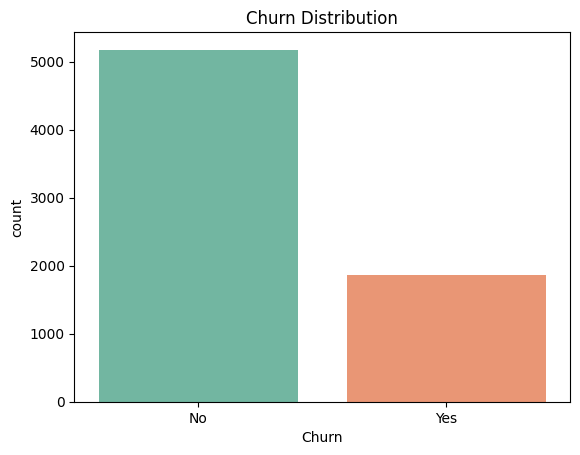

In [3]:
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.show()

In [4]:
# Drop customerID - it's just an identifier, not useful for prediction
df = df.drop(columns=['customerID'])

# TotalCharges is stored as string - convert to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many nulls appeared after conversion
print("Nulls in TotalCharges:", df['TotalCharges'].isnull().sum())

# Fill those nulls with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Convert target column: Yes = 1, No = 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn value counts after encoding:")
print(df['Churn'].value_counts())
print("\nAny remaining nulls:")
print(df.isnull().sum().sum())

Nulls in TotalCharges: 11
Churn value counts after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64

Any remaining nulls:
0


In [5]:
# Separate categorical and numerical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Categorical columns to encode:")
print(cat_cols)

# Encode all categorical columns using get_dummies (one-hot encoding)
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("\nShape after encoding:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Categorical columns to encode:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape after encoding: (7043, 31)

First 3 rows:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [6]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

print("Before SMOTE:")
print("Class distribution:", y.value_counts().to_dict())

# Split first, then apply SMOTE only on training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE (training data only):")
print("Class distribution:", pd.Series(y_train_sm).value_counts().to_dict())
print("\nTraining set size:", X_train_sm.shape)
print("Test set size:", X_test.shape)

Before SMOTE:
Class distribution: {0: 5174, 1: 1869}

After SMOTE (training data only):
Class distribution: {0: 4139, 1: 4139}

Training set size: (8278, 30)
Test set size: (1409, 30)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Scale data for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# Define all 3 models
models = {
    'Logistic Regression': (LogisticRegression(max_iter=2000, random_state=42), X_train_scaled, X_test_scaled),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, random_state=42), X_train_sm, X_test),
    'XGBoost':             (XGBClassifier(eval_metric='logloss', random_state=42), X_train_sm, X_test)
}

# Train and evaluate each model
results = {}

for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train_sm)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Model: Logistic Regression
Accuracy: 0.7594

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1035
           1       0.54      0.63      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.76      1409


Model: Random Forest
Accuracy: 0.7700

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1035
           1       0.56      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409


Model: XGBoost
Accuracy: 0.7686

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1035
           1       0.56      0.57      0.57     

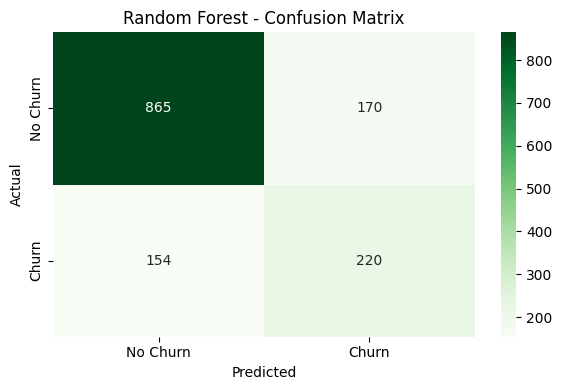

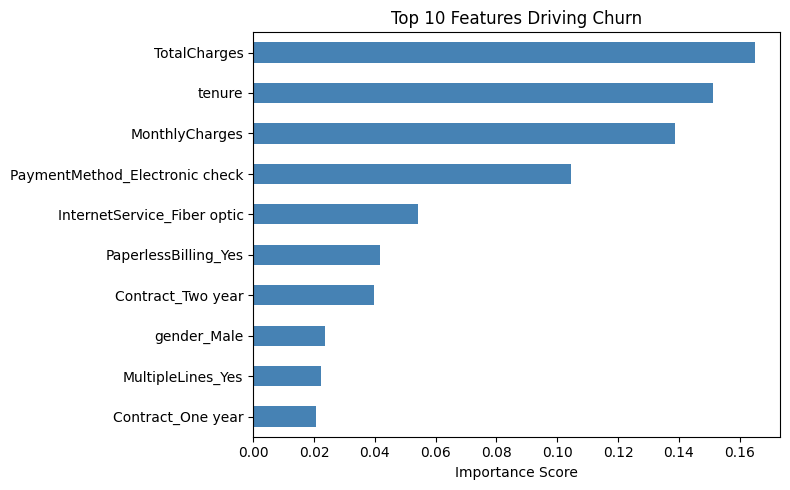

In [9]:
# Confusion matrix for best model (Random Forest)
best_model = models['Random Forest'][0]
X_te_best = models['Random Forest'][2]
y_pred_best = best_model.predict(X_te_best)

plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature importance
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Features Driving Churn')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [10]:
def predict_churn(customer_dict):
    """
    Predict whether a customer will churn or not.
    
    Input: dictionary of customer details
    Output: prediction with probability
    """
    # Convert input to dataframe
    input_df = pd.DataFrame([customer_dict])
    
    # Encode categoricals same way as training data
    input_df = pd.get_dummies(input_df)
    
    # Align columns with training data - fill missing cols with 0
    input_df = input_df.reindex(columns=X.columns, fill_value=0)
    
    # Scale
    input_scaled = scaler.transform(input_df)
    
    # Predict
    pred = best_model.predict(input_df)[0]
    prob = best_model.predict_proba(input_df)[0][1]
    
    result = "WILL CHURN" if pred == 1 else "WILL NOT CHURN"
    print(f"Prediction : {result}")
    print(f"Churn Probability : {prob:.2%}")

# Test it with a sample customer
sample_customer = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 70.35,
    'TotalCharges': 140.70
}

predict_churn(sample_customer)

Prediction : WILL CHURN
Churn Probability : 65.00%


# Customer Churn Prediction Model

## Business Problem
Telecom companies lose significant revenue when customers cancel their subscriptions.
This project builds a machine learning model to predict which customers are likely 
to churn — allowing businesses to intervene early with retention offers.

## Dataset
- Source: IBM Telco Customer Churn Dataset
- Size: 7,043 customers, 20 features
- Target: Churn (Yes/No)

## Approach
1. Data cleaning and preprocessing
2. Handled class imbalance using SMOTE (73% / 27% → 50% / 50%)
3. Trained and compared 3 models: Logistic Regression, Random Forest, XGBoost
4. Selected best model based on accuracy and classification report

## Results
| Model | Accuracy |
|-------|----------|
| Logistic Regression | 75.94% |
| Random Forest | 77.00% |
| XGBoost | 76.86% |

**Best Model: Random Forest — 77% Accuracy**

## Key Findings
- Month-to-month contract customers are the highest churn risk
- Customers with Fiber optic internet and no security addons churn more
- Low tenure (new customers) are significantly more likely to churn

## Tools Used
Python, Pandas, Scikit-learn, XGBoost, Imbalanced-learn, Seaborn, Matplotlib